In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


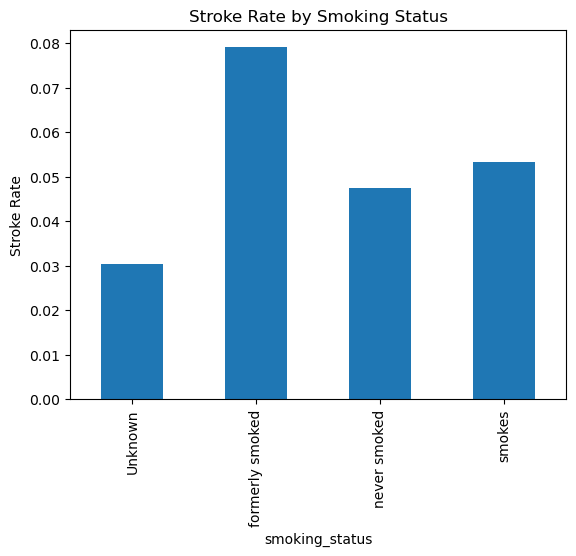

In [3]:
df.groupby('smoking_status')['stroke'].mean().plot(kind='bar')
plt.title('Stroke Rate by Smoking Status')
plt.ylabel('Stroke Rate')
plt.show()

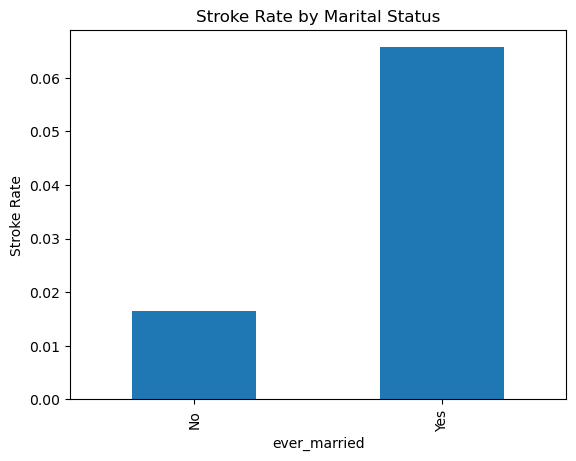

In [4]:
df.groupby('ever_married')['stroke'].mean().plot(kind='bar')
plt.title('Stroke Rate by Marital Status')
plt.ylabel('Stroke Rate')
plt.show()

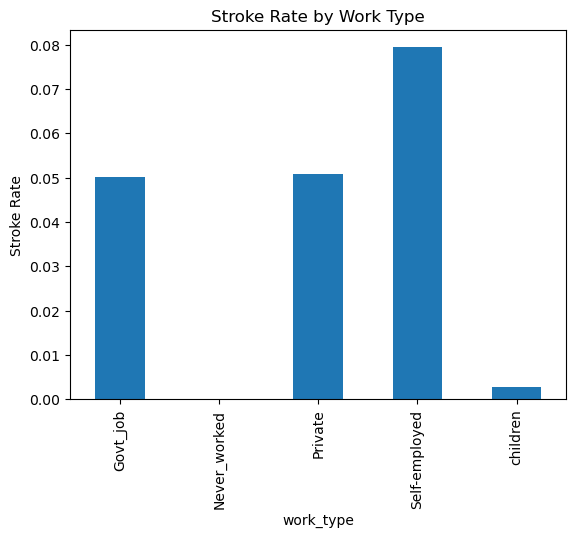

In [5]:
df.groupby('work_type')['stroke'].mean().plot(kind='bar')
plt.title('Stroke Rate by Work Type')
plt.ylabel('Stroke Rate')
plt.show()

In [6]:
df.groupby('stroke')[['bmi', 'avg_glucose_level']].mean()

,bmi,avg_glucose_level
stroke,,
0,28.823064,104.795513
1,30.471292,132.544739


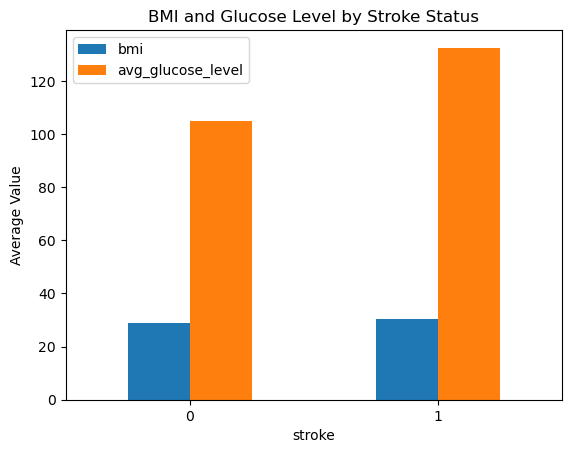

In [7]:
df.groupby('stroke')[['bmi', 'avg_glucose_level']].mean().plot(kind='bar')
plt.title('BMI and Glucose Level by Stroke Status')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.show()

In [8]:
# 处理缺失值（BMI有NaN）
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

In [9]:
df_encoded = pd.get_dummies(df, columns=['smoking_status', 'work_type', 'ever_married'], drop_first=True)

In [10]:
X = df_encoded[['bmi', 'avg_glucose_level',
                'smoking_status_formerly smoked',
                'smoking_status_never smoked',
                'work_type_Private',
                'work_type_Self-employed',
                'ever_married_Yes']]

y = df_encoded['stroke']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [15]:
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.67      0.79       963
           1       0.10      0.61      0.18        59

    accuracy                           0.67      1022
   macro avg       0.53      0.64      0.49      1022
weighted avg       0.92      0.67      0.76      1022



In [16]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)